# **The Baltic Sentinel: Evaluating Estonia’s Energy Resilience**
**Course:** 42578 Advanced Business Analytics


In [14]:
import subprocess, sys

_pkgs = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "geopandas", "geodatasets",
    "requests",
]

for _pkg in _pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=False)

## **1. Introduction - Ursula** 


In early 2026, Estonia's electricity system faced a severe stress event driven by extreme cold, weak wind generation, and major production outages.[1][2][3] This crisis pushed resilience margins to their limits, triggering record-high prices that peaked at 505.06 €/MWh in January and escalated to 655.48 €/MWh by February.[4]

January 2026 was exceptional because multiple stressors aligned perfectly. Decades-low temperatures across the Baltics and Finland coincided with record demand, weak wind, and outages, creating an ideal real-world case study.[3][4] At a strategic level, Estonia's energy transition is moving away from legacy fossil generation toward renewables and modernised infrastructure. The tension between preserving grid reliability and accelerating this transition makes the 2026 crisis especially relevant for evaluating security of supply.[7]

This project analyses that episode as a resilience problem rather than solely a pricing event. The key issue is not just why prices became so high, but what the event reveals about Estonia's ability to maintain a secure electricity supply under disruption. Estonia's system has historically depended on a combination of domestic generation, cross-border imports, and a growing share of renewables, meaning that its stability depends on both internal production and regional interconnection.

A central motivation for this project is the public debate around whether more wind capacity could have changed the outcome. In February 2026, Utilitas Wind published a modelled scenario arguing that the Liivi Bay offshore project could have halved January prices and saved society €75 million, framing wind capacity as a critical resilience measure rather than just a decarbonisation tool.[5]

**Our project therefore asks two linked questions:** 
* **1) How exposed was Estonia's power system during the January 2026 crisis if imports were unavailable?**
* **2) Could planned wind farm expansions have materially improved resilience during those critical hours?**

These questions matter because resilience is determined by system performance in the worst hours, not by average performance in normal conditions.

To answer this, the project combines historical analysis, forecasting, and counterfactual simulation. On the supply side, a spatio-temporal graph neural network is used to model electricity production under different grid states and wind scenarios. On the demand side, a separate forecasting framework estimates hourly consumption and its uncertainty under January 2026 conditions, after which supply and demand are compared under baseline, isolation, and wind-expansion scenarios.

This makes the project more than a forecasting exercise. By combining public reporting, industry claims, and scenario modelling, the project evaluates whether new wind investments would only lower emissions and average prices in normal times, or whether they could also strengthen security of supply during crisis conditions.[5][6]

### References

[1]: ERR News. *January electricity prices highest Estonia has seen in years*. 29 Jan 2026. [https://news.err.ee/1609927241/january-electricity-prices-highest-estonia-has-seen-in-years](https://news.err.ee/1609927241/january-electricity-prices-highest-estonia-has-seen-in-years)

[2]: ERR News. *Cold weather driving up price of electricity, putting production capacity to the test*. 2 Feb 2026. [https://news.err.ee/1609930625/cold-weather-driving-up-price-of-electricity-putting-production-capacity-to-the-test](https://news.err.ee/1609930625/cold-weather-driving-up-price-of-electricity-putting-production-capacity-to-the-test)

[3]: Elenger. *Power market overview Q1 2026*. 13 Apr 2026. [https://elenger.ee/en/power-market-overview-q1-2026/](https://elenger.ee/en/power-market-overview-q1-2026/)

[4]: Konkurentsiamet. *Energiaturgude ülevaade veebruar 2026*. April 2026. [https://www.konkurentsiamet.ee/sites/default/files/documents/2026-04/Energiaturgude%20%C3%BClevaade%20veebruar%202026.pdf](https://www.konkurentsiamet.ee/sites/default/files/documents/2026-04/Energiaturgude%20%C3%BClevaade%20veebruar%202026.pdf)

[5]: Ärileht / Delfi. *Utilitas Windi juht: tuulepargid võinuks jaanuari elektrihinna pooleks lüüa ja säästa kümneid miljoneid*. 17 Feb 2026. <https://arileht.delfi.ee/artikkel/120436765/utilitas-windi-juht-tuulepargid-voinuks-jaanuari-elektrihinna-pooleks-luua-ja-saasta-kumneid-miljoneid>

[6]: European Commission. *Estonia's recovery and resilience plan*. [https://reforms-investments.ec.europa.eu/recovery-and-resilience-facility-1/country-pages/estonias-recovery-and-resilience-plan_en](https://reforms-investments.ec.europa.eu/recovery-and-resilience-facility-1/country-pages/estonias-recovery-and-resilience-plan_en)

In [15]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys
import os

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## **2. Data - Sofie**

Our analysis uses a modular pipeline to isolate and recombine the two sides of the grid equation. 

### **2.1 Data Sources**
*   **Grid Operations (Elering):** Hourly production, consumption, and cross-border flow data[cite: 3].
*   **Market Pricing (Nord Pool):** Day-Ahead clearing prices for the EE, FI, and LV bidding zones[cite: 3].
*   **Environment (OpenWeather API):** Historical temperature and wind speeds for specific coordinates[cite: 3].

### **2.2 Wind Capacity Scenarios** 
*   **Baseline (Current):** **694 MW** of grid-connected wind[cite: 1].
*   **Scenario A (Established):** Adding **323 MW** from Pärnu and Aidu[cite: 1].
*   **Scenario B (Full Pipeline):** Adding a total of **887 MW** of new capacity[cite: 1].

In [ ]:
# Define capacities based on Project Advanced BA
CURRENT_WIND_MW = 694.0
SCENARIO_A_MW = CURRENT_WIND_MW + 323.0
SCENARIO_B_MW = CURRENT_WIND_MW + 887.0

# Physical Grid Limits (MW)
ESTLINK_CAPACITY = 1016  
LATVIA_CAPACITY = 700    

print(f"Baseline Wind: {CURRENT_WIND_MW} MW")
print(f"Scenario A (Established) Wind: {SCENARIO_A_MW} MW")
print(f"Scenario B (Full Pipeline) Wind: {SCENARIO_B_MW} MW")

## **3. Exploratory Data Analysis: Visualizing the Crisis**
Before modeling, we must understand the magnitude of the "Perfect Storm" in January 2026. Here, we visualize the temperature-demand trap, the EstLink failure cliff, and regional price divergence.

In [ ]:
# Load historical data (placeholder paths - update with actual data from sandra359/advanced_ba)
# df_historical = pd.read_csv('data/historical_jan2026.csv')

# TODO: Plot 1: Temperature vs. Consumption Spikes
# TODO: Plot 2: EstLink Flow (showing the drop to 0 MW)
# TODO: Plot 3: Nord Pool Price Divergence (EE vs FI vs LV)

## **4. Demand Analysis: Probabilistic Forecasting - Sofie**

Resilience is tested against extremes. We use an **ARIMAX** model to predict hourly consumption, accounting for temperature and temporal features[cite: 3].

To identify "edge-case" demand, we perform a **Monte Carlo simulation** using the model’s residual standard deviation. This allows us to extract a **P95 Worst-Case Demand** curve, ensuring our stress test targets a 1-in-100-year consumption spike[cite: 3].

In [ ]:
# The ARIMAX model and Monte Carlo simulation logic are executed in Demand.py.
# Here, we load the pre-calculated P95 Worst-Case Demand curve for January 2026.

# demand_df = pd.read_csv("data/demand_p95_jan2026.csv")
# demand_df['timestamp'] = pd.to_datetime(demand_df['timestamp'])

# TODO: Visualize the P50 (Average) vs P95 (Worst-Case) Demand Forecast

## **5. Wind Counterfactual Simulation — Ursula**

Assessing whether new wind farms would have materially changed January 2026 requires two analytical steps. First, we establish the historical context of Estonia's existing wind fleet using actual ENTSOE Transparency Platform metered production data (2019–2025). Second, since the planned farms do not yet exist, we estimate their January 2026 output using ERA5 reanalysis weather and a physical turbine power curve model.

The full data pipelines are implemented as standalone scripts (all paths relative to `final_project/`):
- `wind_farm_locations.py` — loads Land Board GIS polygons from `data/wind_farm_locations/`, extracts polygon centroids → farm coordinates used below
- `wind_integration.py` — parses ENTSOE CSV exports from `data/historical_production_data/`, handles DST ambiguity, computes capacity factors → `../data/entsoe_production_hourly.csv`
- `wind_counterfactual.py` — fetches ERA5 weather per farm centroid via Open-Meteo, applies Vestas V150 power curve → `../data/wind_production_scenarios.csv`

**Data sources:**
- ENTSOE Transparency Platform: [transparency.entsoe.eu](https://transparency.entsoe.eu) — metered generation by type, 2019–2025, files in `data/historical_production_data/`
- Open-Meteo ERA5 archive API: [open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api) — free, no key required, ~9 km resolution
- Estonian Land Board (Maa-amet) — wind-energy planning-area GeoJSON files in `data/wind_farm_locations/`
- Elering annual reports — installed wind capacity timeline (310 MW 2019 → 694 MW 2025)

### 5.1 Historical Wind Context (ENTSOE 2019–2025)

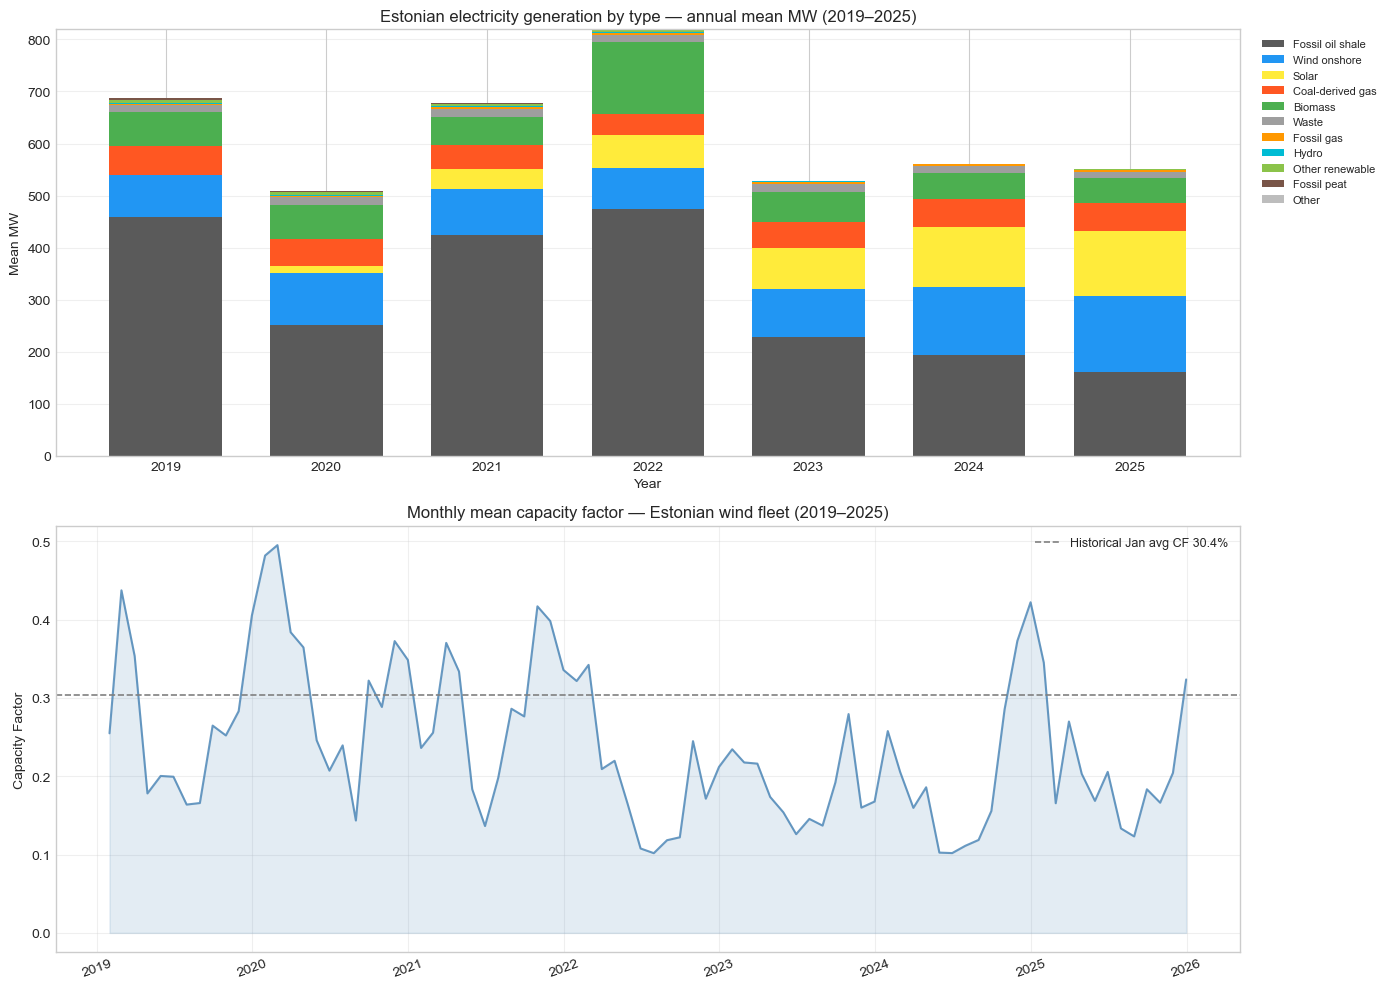

Historical January mean CF (2019–2025): 0.304
January 2026 counterfactual CF (ERA5):   0.152  (about half the average)


In [21]:
import os
os.makedirs("../figures", exist_ok=True)

RENAME = {
    "fossil_oil_shale":               "Fossil oil shale",
    "biomass":                        "Biomass",
    "wind_onshore":                   "Wind onshore",
    "fossil_gas":                     "Fossil gas",
    "fossil_peat":                    "Fossil peat",
    "waste":                          "Waste",
    "other_renewable":                "Other renewable",
    "other":                          "Other",
    "solar":                          "Solar",
    "hydro_run-of-river_and_pondage": "Hydro",
    "fossil_coal-derived_gas":        "Coal-derived gas",
}
COLORS = {
    "Fossil oil shale": "#5a5a5a", "Biomass": "#4caf50",    "Wind onshore": "#2196f3",
    "Fossil gas":       "#ff9800", "Fossil peat": "#795548", "Waste": "#9e9e9e",
    "Other renewable":  "#8bc34a", "Other": "#bdbdbd",       "Solar": "#ffeb3b",
    "Hydro":            "#00bcd4", "Coal-derived gas": "#ff5722",
}

try:
    entsoe = pd.read_csv("../data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    gen_cols = [c for c in entsoe.columns if c not in ("capacity_factor", "installed_mw")]

    annual = entsoe[gen_cols].loc["2019":"2025"].resample("YE").mean()
    annual.index = annual.index.year
    annual_named = annual.rename(columns=RENAME).fillna(0)
    col_order = annual_named.loc[2025].sort_values(ascending=False).index.tolist()
    annual_named = annual_named[col_order]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Annual energy mix stacked bar
    bottom = np.zeros(len(annual_named))
    for col in col_order:
        vals = annual_named[col].values
        axes[0].bar(annual_named.index, vals, bottom=bottom,
                    label=col, color=COLORS.get(col, "#aaaaaa"), width=0.7)
        bottom += vals
    axes[0].set_title("Estonian electricity generation by type — annual mean MW (2019–2025)", fontsize=12)
    axes[0].set_ylabel("Mean MW")
    axes[0].set_xlabel("Year")
    axes[0].set_xticks(annual_named.index)
    axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    axes[0].grid(axis="y", alpha=0.3)

    # Plot 2: Monthly capacity factor
    cf_monthly = entsoe["capacity_factor"].loc["2019":"2025"].resample("ME").mean()
    axes[1].plot(cf_monthly.index, cf_monthly.values, color="steelblue", lw=1.5, alpha=0.8)
    axes[1].axhline(0.304, color="gray", lw=1.2, linestyle="--", label="Historical Jan avg CF 30.4%")
    axes[1].fill_between(cf_monthly.index, cf_monthly.values, alpha=0.15, color="steelblue")
    axes[1].set_title("Monthly mean capacity factor — Estonian wind fleet (2019–2025)", fontsize=12)
    axes[1].set_ylabel("Capacity Factor")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.savefig("../figures/entsoe_historical_wind.png", dpi=150, bbox_inches="tight")
    plt.show()

    jan_cf = entsoe.loc[entsoe.index.month == 1, "capacity_factor"].mean()
    print(f"Historical January mean CF (2019–2025): {jan_cf:.3f}")
    print(f"January 2026 counterfactual CF (ERA5):   0.152  (about half the average)")
except FileNotFoundError as e:
    print(f"Missing: {e}\nRun: python wind_integration.py")

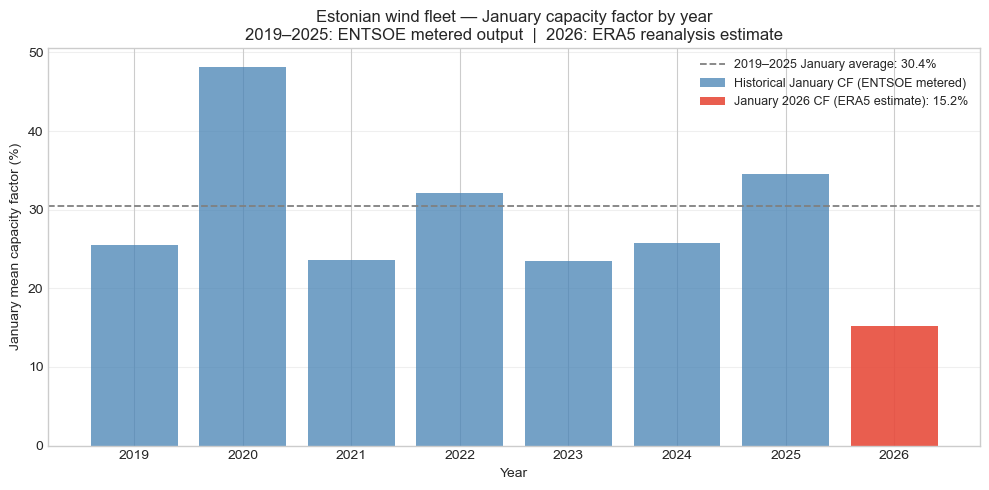

January mean capacity factors:
  2019: 25.5%
  2020: 48.2%
  2021: 23.6%
  2022: 32.2%
  2023: 23.4%
  2024: 25.8%
  2025: 34.5%
  2026 (ERA5): 15.2%  ← lowest on record


In [17]:
try:
    entsoe = pd.read_csv("../data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    wind_scen = pd.read_csv("../data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_scen.index.tz is None:
        wind_scen.index = wind_scen.index.tz_localize("UTC")

    jan_hist = entsoe[entsoe.index.month == 1]
    jan_cf_by_year = jan_hist.groupby(jan_hist.index.year)["capacity_factor"].mean()
    jan26_cf = wind_scen["wind_mwh_baseline"].mean() / 694

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(jan_cf_by_year.index, jan_cf_by_year.values * 100,
           color="steelblue", alpha=0.75, label="Historical January CF (ENTSOE metered)")
    ax.bar([2026], [jan26_cf * 100], color="#e74c3c", alpha=0.9,
           label=f"January 2026 CF (ERA5 estimate): {jan26_cf*100:.1f}%")
    ax.axhline(jan_cf_by_year.mean() * 100, color="gray", lw=1.3, linestyle="--",
               label=f"2019\u20132025 January average: {jan_cf_by_year.mean()*100:.1f}%")
    ax.set_xlabel("Year")
    ax.set_ylabel("January mean capacity factor (%)")
    ax.set_title("Estonian wind fleet \u2014 January capacity factor by year\n"
                 "2019\u20132025: ENTSOE metered output  |  2026: ERA5 reanalysis estimate")
    ax.set_xticks(list(jan_cf_by_year.index) + [2026])
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../figures/jan_cf_by_year.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("January mean capacity factors:")
    for yr, cf in jan_cf_by_year.items():
        print(f"  {yr}: {cf*100:.1f}%")
    print(f"  2026 (ERA5): {jan26_cf*100:.1f}%  \u2190 lowest on record")
except FileNotFoundError as e:
    print(f"Missing: {e}")

### 5.2 Counterfactual Scenarios — Farm Locations and Methodology

Since the planned farms do not yet exist, there is no metered output to download. We estimate production using **ERA5 reanalysis wind speeds at 100 m** (from Open-Meteo's free archive API) at each farm's GIS centroid, combined with a **Vestas V150-4.5 MW power curve** and an air-density correction for cold January conditions. A flat capacity addition would assume every new MW operates at the same average CF as the existing fleet — ignoring that specific farm locations have different wind regimes and that calm-wind hours (when the crisis was worst) affect all sites simultaneously. The ERA5 + power curve approach captures this hour-by-hour variability.

**Scenario A — established plans (+323 MW, total 1,017 MW):**

| Farm | Capacity | Planning status | Source file |
|------|----------|----------------|-------------|
| Lääneranna (area 2) | 137 MW | Valid special plan (*kehtestatud eriplaneeringu asukoha eelvalik*) | `tuul_ep_kehtestatud.geojson` |
| Pärnu + Tori (Põlendmaa) | 86 MW | Valid special plan | `tuul_ep_kehtestatud.geojson` |
| Aidu renewable energy park | 100 MW | Valid detailed plan (*kehtestatud detailplaneering*) | `tuulealad_DP.geojson` |

**Scenario B — pipeline plans (+564 MW on top of A, total 1,581 MW):**

| Farm | Capacity | Planning status | Source file |
|------|----------|----------------|-------------|
| Lääneranna (pipeline areas) | 150 MW | SEA report adopted, moving towards implementation | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Tori rural municipality | 100 MW | SEA report adopted | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Lääne-Nigula | 100 MW | Location decision published | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Põhja-Pärnumaa | 100 MW | Draft stage I and SEA published | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Lüganuse (Evecon + Enery Estonia) | 114 MW | Draft stage I and SEA published | `tuuleenergeetika_KOV_EP_alad.geojson` |

*GIS source: Estonian Land Board (Maa-amet) planning-area GeoJSON files in `data/wind_farm_locations/`. Capacity figures for Scenario A are from the officially enacted planning documents. Scenario B capacities are proportional estimates based on planning-area polygon size (7 MW/km²) as exact MW have not yet been published. Farm coordinates derived by `wind_farm_locations.py` (polygon centroid extraction, EPSG:4326).*

> **Note — onshore only:** Estonia currently has **no offshore wind farms**. All 694 MW of installed capacity, and all farms in Scenarios A and B, are onshore. The Utilitas Liivi Bay offshore project referenced in the introduction [5] would be a separate, much larger category and is not included in this counterfactual.

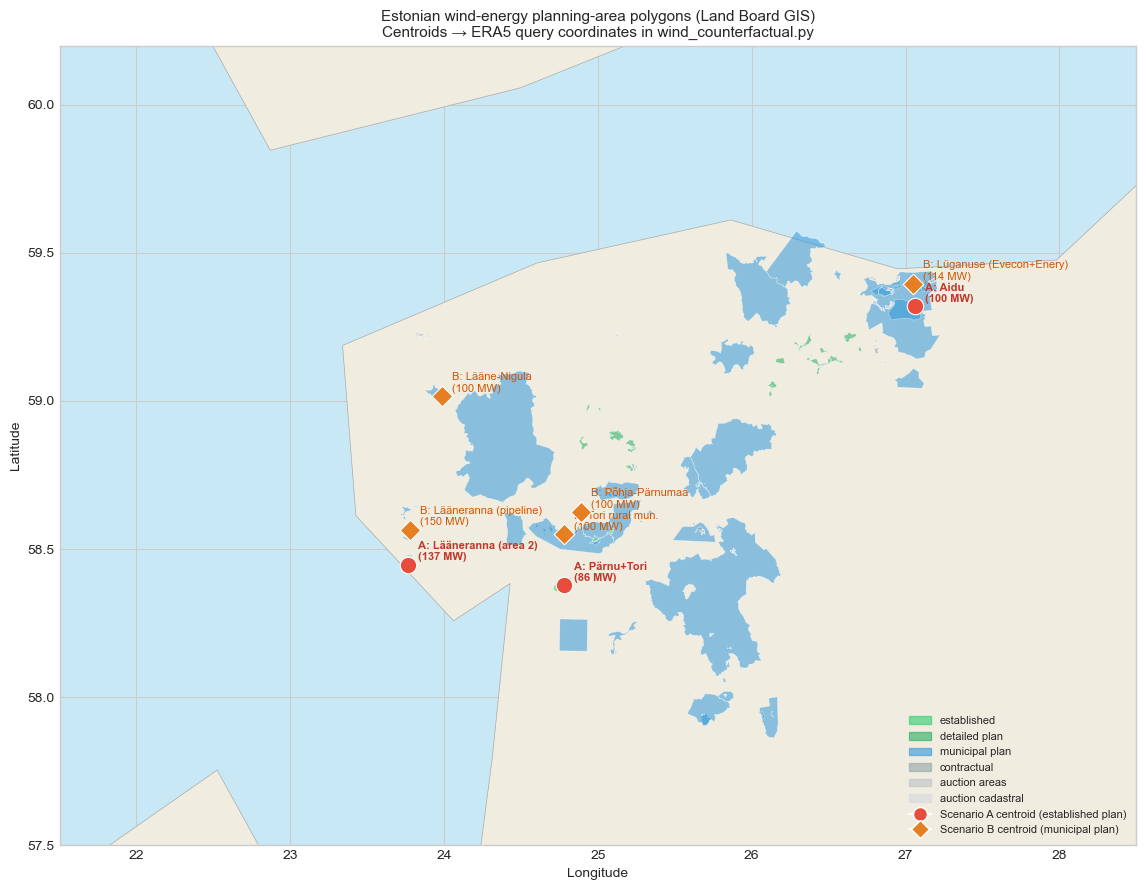

Full GIS pipeline: wind_farm_locations.py


In [22]:
import geopandas as gpd
import matplotlib.patches as mpatches
import importlib

GIS_DIR = "../data/wind_farm_locations"

LON_MIN, LON_MAX = 21.5, 28.5
LAT_MIN, LAT_MAX = 57.5, 60.2

FILES = {
    "tuul_ep_kehtestatud.geojson":                    ("established",       "#2ecc71"),
    "tuulealad_DP.geojson":                           ("detailed plan",     "#27ae60"),
    "tuuleenergeetika_KOV_EP_alad.geojson":           ("municipal plan",    "#3498db"),
    "RMK_MARU_lepingus.geojson":                      ("contractual",       "#95a5a6"),
    "Riigimaade_enampakkumine_voor_alad.geojson":     ("auction areas",     "#bdc3c7"),
    "Riigimaade_enampakkumine_voor_kataster.geojson": ("auction cadastral", "#d5d8dc"),
}
SCEN_A = {
    "Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas":
        ("Lääneranna (area 2)", 137, 58.4473, 23.7673),
    "Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)":
        ("Pärnu+Tori", 86, 58.3775, 24.7786),
    "Aidu ja Aidu-Liiva":
        ("Aidu", 100, 59.3195, 27.0613),
}
SCEN_B = [
    ("Lääneranna (pipeline)", 150, 58.5658, 23.7781),
    ("Tori rural mun.",       100, 58.5496, 24.7787),
    ("Lääne-Nigula",          100, 59.0159, 23.9870),
    ("Põhja-Pärnumaa",        100, 58.6254, 24.8906),
    ("Lüganuse (Evecon+Enery)", 114, 59.3959, 27.0476),
]

try:
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.set_facecolor("#c9e8f5")

    land = None
    try:
        _gds = importlib.import_module("geodatasets")
        land = gpd.read_file(_gds.get_path("naturalearth.land"))
    except Exception:
        try:
            _ds = getattr(gpd, "datasets", None)
            if _ds is not None:
                land = gpd.read_file(_ds.get_path("naturalearth_lowres"))
        except Exception:
            pass
    if land is not None:
        land.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX].plot(
            ax=ax, color="#f0ede0", edgecolor="#aaaaaa", linewidth=0.5, zorder=1)

    for fname, (label, color) in FILES.items():
        gdf = gpd.read_file(f"{GIS_DIR}/{fname}")
        if gdf.crs is None:
            gdf = gdf.set_crs(epsg=4326)
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
        gdf.plot(ax=ax, color=color, alpha=0.55, edgecolor="white", linewidth=0.4, zorder=2)

    for name, (lbl, mw, lat, lon) in SCEN_A.items():
        ax.scatter(lon, lat, s=140, color="#e74c3c", zorder=6, edgecolors="white", linewidths=0.8)
        ax.annotate(f"A: {lbl}\n({mw} MW)", (lon, lat),
                    textcoords="offset points", xytext=(7, 3),
                    fontsize=8, color="#c0392b", fontweight="bold")
    for lbl, mw, lat, lon in SCEN_B:
        ax.scatter(lon, lat, s=110, color="#e67e22", zorder=5, marker="D",
                   edgecolors="white", linewidths=0.8)
        ax.annotate(f"B: {lbl}\n({mw} MW)", (lon, lat),
                    textcoords="offset points", xytext=(7, 3),
                    fontsize=8, color="#d35400")

    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for _, (l, c) in FILES.items()]
    patches += [
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#e74c3c",
                   markersize=10, label="Scenario A centroid (established plan)"),
        plt.Line2D([0],[0], marker="D", color="w", markerfacecolor="#e67e22",
                   markersize=9, label="Scenario B centroid (municipal plan)"),
    ]
    ax.legend(handles=patches, fontsize=8, loc="lower right", framealpha=0.9)
    ax.set_title("Estonian wind-energy planning-area polygons (Land Board GIS)\n"
                 "Centroids → ERA5 query coordinates in wind_counterfactual.py", fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig("../figures/wind_farm_gis_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Full GIS pipeline: wind_farm_locations.py")
except Exception as e:
    print(f"Error: {e}")
    print("Requires geopandas. Install geodatasets for land background: pip install geodatasets")

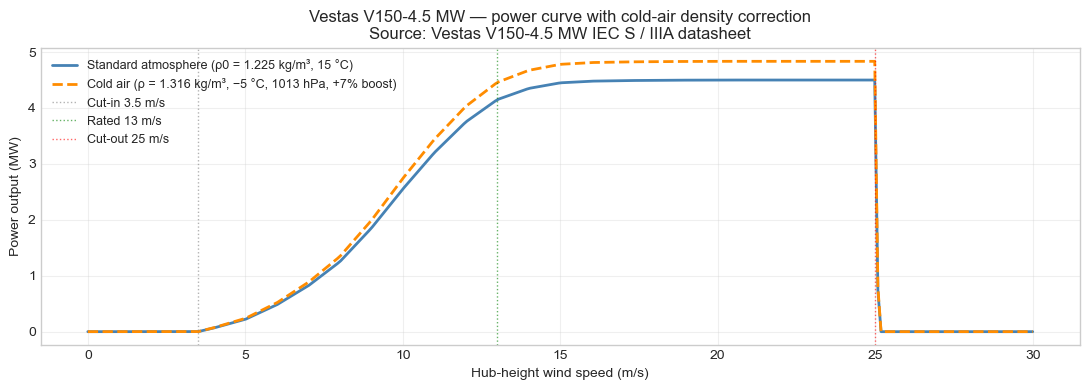

Air density at −5 °C, 1013 hPa: 1.3161 kg/m³  (+7.4% vs standard)


In [23]:
import numpy as np

# Vestas V150-4.5 MW power curve (cut-in ~3.5 m/s, rated ~13 m/s, cut-out 25 m/s)
# Source: Vestas V150-4.5 MW IEC S / IIIA datasheet
PC_WS = np.array([0,1,2,3,3.5,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,25.1,50])
PC_KW = np.array([0,0,0,0,  0,66,220,480,820,1250,1850,2550,3200,3750,4150,4350,4450,4480,4490,4495,4498,4500,4500,4500,4500,4500,4500,0,0])

v = np.linspace(0, 30, 300)
rho_std  = 1.225
rho_cold = (1013 * 100) / (287.05 * (-5 + 273.15))
boost_pct = (rho_cold / rho_std - 1) * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(v, np.interp(v, PC_WS, PC_KW) / 1000,
        color="steelblue", lw=2, label=f"Standard atmosphere (\u03c10 = 1.225 kg/m\u00b3, 15 \u00b0C)")
ax.plot(v, np.interp(v, PC_WS, PC_KW) * (rho_cold / rho_std) / 1000,
        color="darkorange", lw=2, linestyle="--",
        label=f"Cold air (\u03c1 = {rho_cold:.3f} kg/m\u00b3, \u22125 \u00b0C, 1013 hPa, +{boost_pct:.0f}% boost)")
ax.axvline(3.5, color="gray",  lw=1, linestyle=":", alpha=0.6, label="Cut-in 3.5 m/s")
ax.axvline(13,  color="green", lw=1, linestyle=":", alpha=0.6, label="Rated 13 m/s")
ax.axvline(25,  color="red",   lw=1, linestyle=":", alpha=0.6, label="Cut-out 25 m/s")
ax.set_xlabel("Hub-height wind speed (m/s)")
ax.set_ylabel("Power output (MW)")
ax.set_title("Vestas V150-4.5 MW — power curve with cold-air density correction\n"
             "Source: Vestas V150-4.5 MW IEC S / IIIA datasheet")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/power_curve_v150.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Air density at \u22125 \u00b0C, 1013 hPa: {rho_cold:.4f} kg/m\u00b3  (+{boost_pct:.1f}% vs standard)")

### 5.3 Power Curve Model

**Hub-height wind speed.** The Vestas V150 hub sits at 105 m. ERA5 provides `wind_speed_100m` at 100 m — 5 m below hub. Applying the standard power-law wind shear correction gives a factor of $(105/100)^{0.143} \approx 1.007$, a 0.7% difference negligible compared to ERA5 reanalysis uncertainty. The 100 m wind speed is therefore used directly as the hub-height proxy.

**Air density correction.** The published power curve assumes standard atmosphere ($\rho_0 = 1.225$ kg/m³ at 15 °C, sea level). Cold, dense winter air contains more kinetic energy per cubic metre. ERA5 provides hourly temperature $T$ (°C) and surface pressure $p$ (hPa), from which air density is computed via the ideal gas law:

$$\rho = \frac{p \times 100}{287.05 \times (T + 273.15)} \quad \text{[kg/m}^3\text{]}$$

Because turbine power scales with air density, the corrected output is:

$$P_\text{adj}(v) = P_\text{nominal}(v) \times \frac{\rho}{\rho_0}$$

At the January 2026 crisis conditions (around −5 °C, 1013 hPa), $\rho \approx 1.316$ kg/m³ — roughly 7% above standard — giving a ~7% power boost relative to the IEC reference condition. Cold temperatures therefore slightly *favour* turbine output, working in Estonia's direction during the crisis.

**Capacity factor and farm production.** The capacity factor at each hour is $\text{CF} = \min(1,\; P_\text{adj} / 4500\text{ kW})$. Multiplied by each farm's installed MW and summed across farms, this gives total hourly wind production per scenario.

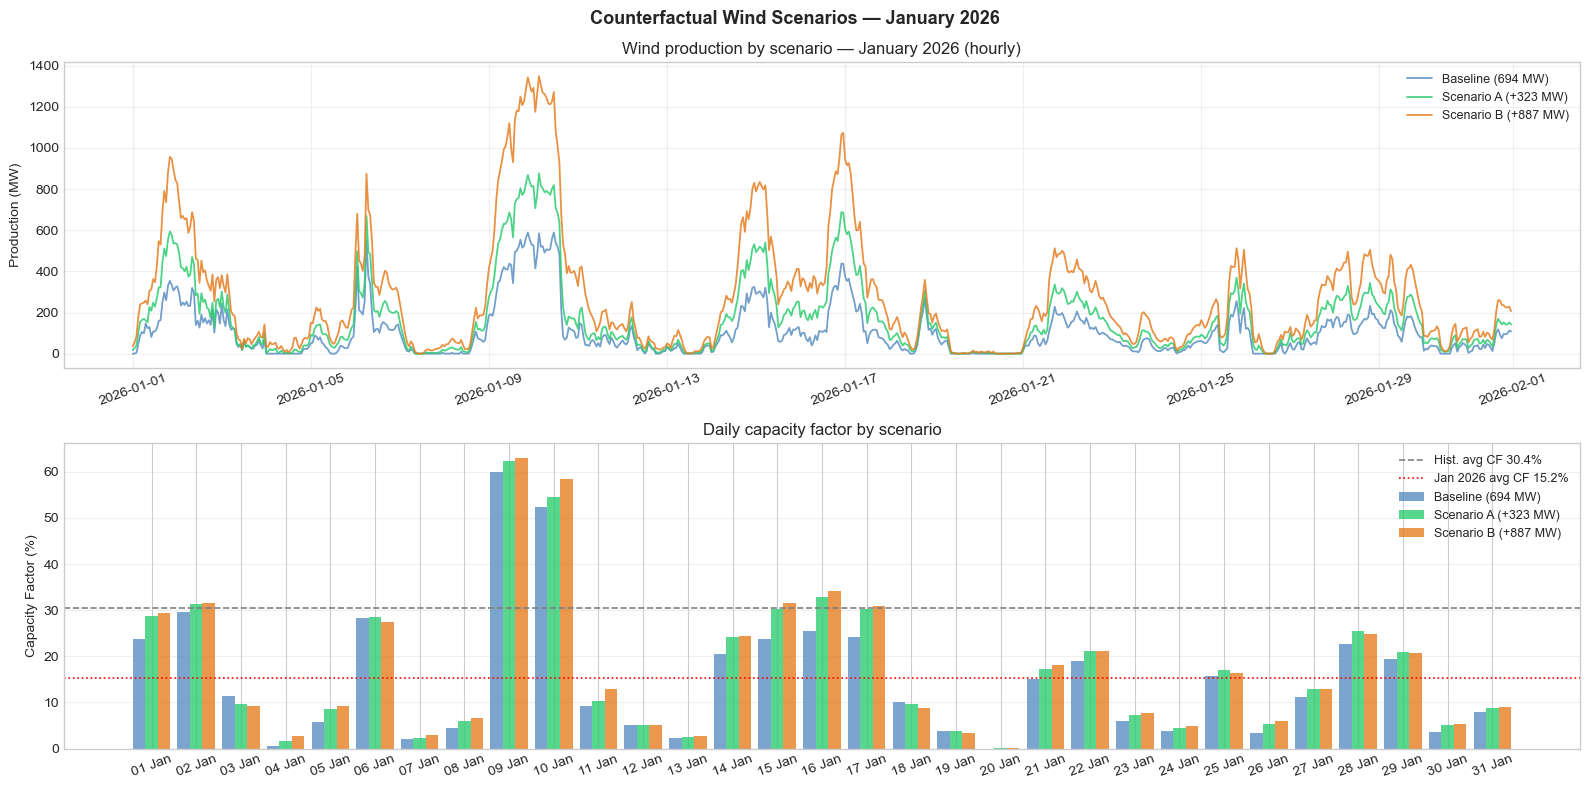

Mean production (MW):
  Baseline (694 MW)           : 105.3 MW  (CF 15.2%)
  Scenario A (+323 MW)        : 173.1 MW  (CF 17.0%)
  Scenario B (+887 MW)        : 276.3 MW  (CF 17.5%)


In [24]:
try:
    wind_df = pd.read_csv("../data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_df.index.tz is None:
        wind_df.index = wind_df.index.tz_localize("UTC")

    wind_df = wind_df.rename(columns={
        "wind_mwh_baseline": "Baseline (694 MW)",
        "wind_mwh_scenA":    "Scenario A (+323 MW)",
        "wind_mwh_scenB":    "Scenario B (+887 MW)",
    })
    RATED = {"Baseline (694 MW)": 694, "Scenario A (+323 MW)": 1017, "Scenario B (+887 MW)": 1581}
    SCEN_COLORS = ["#5a8fc2", "#2ecc71", "#e67e22"]
    daily = wind_df.resample("D").mean()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    # Hourly time series
    for col, clr in zip(wind_df.columns, SCEN_COLORS):
        axes[0].plot(wind_df.index, wind_df[col].values, color=clr, lw=1.3, alpha=0.85, label=col)
    axes[0].set_title("Wind production by scenario — January 2026 (hourly)")
    axes[0].set_ylabel("Production (MW)")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=20)

    # Daily capacity factor
    x = np.arange(len(daily))
    w = 0.28
    for i, (col, clr) in enumerate(zip(daily.columns, SCEN_COLORS)):
        cf = daily[col] / RATED[col] * 100
        axes[1].bar(x + (i - 1) * w, cf.values, w, color=clr, alpha=0.8, label=col)
    axes[1].axhline(30.4, color="gray", lw=1.2, linestyle="--", label="Hist. avg CF 30.4%")
    axes[1].axhline(15.2, color="red",  lw=1.2, linestyle=":",  label="Jan 2026 avg CF 15.2%")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([d.strftime("%d %b") for d in daily.index], rotation=20)
    axes[1].set_title("Daily capacity factor by scenario")
    axes[1].set_ylabel("Capacity Factor (%)")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Counterfactual Wind Scenarios — January 2026", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../figures/wind_scenarios_jan2026.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Mean production (MW):")
    for col in wind_df.columns:
        print(f"  {col:28s}: {wind_df[col].mean():.1f} MW  (CF {wind_df[col].mean()/RATED[col]*100:.1f}%)")
except FileNotFoundError as e:
    print(f"Missing: {e}\nRun: python wind_counterfactual.py")

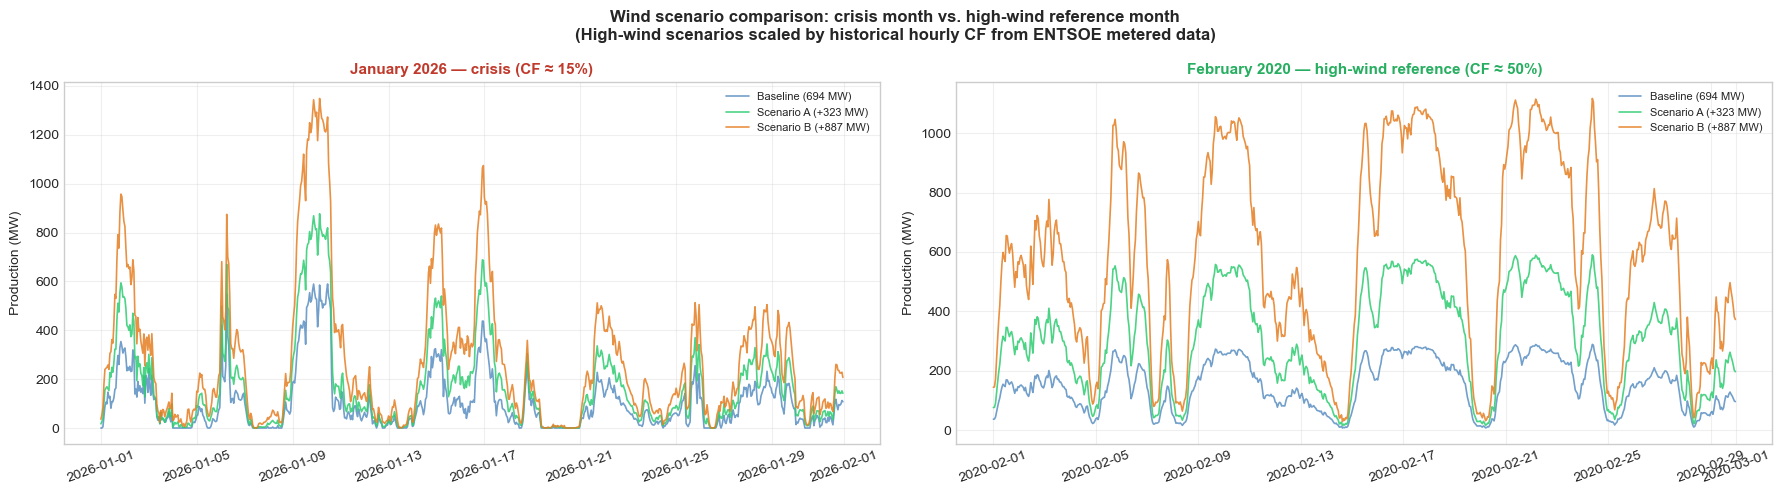

January 2026  — mean baseline: 105 MW  | scenA: 173 MW  | scenB: 276 MW
February 2020 — mean baseline: 153 MW  | scenA: 313 MW  | scenB: 593 MW


In [25]:
try:
    entsoe = pd.read_csv("../data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    wind_df = pd.read_csv("../data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_df.index.tz is None:
        wind_df.index = wind_df.index.tz_localize("UTC")

    # Find the highest-CF full month in 2019–2025 (at least 28*24 hours of data)
    monthly_cf = entsoe["capacity_factor"].loc[:"2025-12"].resample("ME").agg(
        lambda x: x.mean() if len(x) >= 24*28 else float("nan")
    ).dropna()
    best_ts = monthly_cf.idxmax()
    best_label = best_ts.strftime("%B %Y")

    best = entsoe.loc[best_ts.strftime("%Y-%m")]
    base_mw  = best["wind_onshore"].fillna(0)
    cf_hour  = best["capacity_factor"].fillna(0)
    scenA_best = base_mw + cf_hour * 323
    scenB_best = base_mw + cf_hour * 887

    # January 2026 data already loaded
    j26 = wind_df.rename(columns={
        "wind_mwh_baseline": "Baseline (694 MW)",
        "wind_mwh_scenA":    "Scenario A (+323 MW)",
        "wind_mwh_scenB":    "Scenario B (+887 MW)",
    })

    SCEN_COLORS = ["#5a8fc2", "#2ecc71", "#e67e22"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # Left: January 2026 (crisis)
    for col, clr in zip(j26.columns, SCEN_COLORS):
        axes[0].plot(j26.index, j26[col].values, color=clr, lw=1.2, alpha=0.85, label=col)
    axes[0].set_title(f"January 2026 — crisis (CF ≈ 15%)", fontsize=11, fontweight="bold", color="#c0392b")
    axes[0].set_ylabel("Production (MW)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=20)

    # Right: best historical month
    axes[1].plot(best.index, base_mw.values,     color=SCEN_COLORS[0], lw=1.2, alpha=0.85, label="Baseline (694 MW)")
    axes[1].plot(best.index, scenA_best.values,  color=SCEN_COLORS[1], lw=1.2, alpha=0.85, label="Scenario A (+323 MW)")
    axes[1].plot(best.index, scenB_best.values,  color=SCEN_COLORS[2], lw=1.2, alpha=0.85, label="Scenario B (+887 MW)")
    axes[1].set_title(f"{best_label} — high-wind reference (CF ≈ {monthly_cf[best_ts]*100:.0f}%)",
                      fontsize=11, fontweight="bold", color="#27ae60")
    axes[1].set_ylabel("Production (MW)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=20)

    plt.suptitle("Wind scenario comparison: crisis month vs. high-wind reference month\n"
                 "(High-wind scenarios scaled by historical hourly CF from ENTSOE metered data)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../figures/wind_scenario_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"January 2026  — mean baseline: {j26['Baseline (694 MW)'].mean():.0f} MW  "
          f"| scenA: {j26['Scenario A (+323 MW)'].mean():.0f} MW  "
          f"| scenB: {j26['Scenario B (+887 MW)'].mean():.0f} MW")
    print(f"{best_label} — mean baseline: {base_mw.mean():.0f} MW  "
          f"| scenA: {scenA_best.mean():.0f} MW  "
          f"| scenB: {scenB_best.mean():.0f} MW")
except FileNotFoundError as e:
    print(f"Missing: {e}")

### 5.4 Key Findings

January 2026 was the lowest-wind January on record for Estonia's fleet, with an ERA5-estimated capacity factor of approximately **15.2%** against a 2019–2025 January average of ~30.4% (ENTSOE metered). The comparison with a high-wind reference month above shows what the same scenarios produce when the fleet runs near its potential: in a good-wind month the Scenario B additions (~887 MW) can contribute several hundred MW of additional output. During January 2026, the same capacity added only ~171 MW on average — and near zero in the calm-wind hours that drove the price spikes.

Key results under January 2026 actual weather:
- **Baseline (694 MW):** ~105 MW mean production (CF ≈ 15%)
- **Scenario A (+323 MW → 1,017 MW total):** ~173 MW mean  (+68 MW over baseline)
- **Scenario B (+887 MW → 1,581 MW total):** ~276 MW mean  (+171 MW over baseline)

**Why wind alone cannot solve the crisis.** During the worst hours — when demand peaked and prices hit €505/MWh — wind from all three scenarios simultaneously approached zero. Additional onshore capacity reduces the frequency and average depth of deficits, but provides no firm power during calm-wind events. Storage or dispatchable backup is required to cover the residual.

**Context on Estonia's wind mix.** All 694 MW of currently installed capacity, and all farms modelled in Scenarios A and B, are **onshore**. Estonia has no offshore wind in operation. The Utilitas Liivi Bay offshore project [5] would face different wind regimes (stronger, more consistent sea winds) and is therefore not directly comparable to the onshore counterfactuals estimated here.

## **6. Supply Analysis: Spatio-Temporal GNN - Sandra & Tomas**

The Estonian grid is a geographic network. We use a **Spatio-Temporal Graph Neural Network (ST-GNN)** to model how energy flows and market prices propagate across nodes[cite: 3].

*   **Quantile Regression:** The GNN natively outputs **P10 (Worst-Case Supply)**, P50, and P90, handling supply-side uncertainty without a second Monte Carlo simulation[cite: 3]. 
*   **"Market Blindness":** To simulate the crisis, we sever the graph edges to Finland. This forces the model to predict domestic production in **Island Mode**, reacting only to local weather rather than Nordic market prices[cite: 3].

In [ ]:
# ST-GNN training and inference are executed in Supply_wind.py.
# We load the output predictions for the 4 scenarios.

try:
    supply_df = pd.read_csv("data/gnn_supply_scenarios_jan2026.csv")
    supply_df['timestamp'] = pd.to_datetime(supply_df['timestamp'])
    print("GNN Supply Scenarios Loaded Successfully.")
except FileNotFoundError:
    print("Placeholder: Awaiting output from Supply_wind.py")

# TODO: Visualize the P10 Supply Baseline vs P10 Supply with +887MW Wind

## **7. Resilience Simulation: The Balance Equation - Sandra & Tomas**

This is the final "Stress Test" where we combine our independent models to calculate the physical blackout threshold.

We calculate the hourly deficit under isolation using the formula:
**Hourly Deficit = Demand(P95) - Domestic Production(P10)**

We apply the physical constraints of the grid:
*   **Scenario 1:** Full connectivity (EstLink + Latvia).
*   **Scenario 2:** **EstLink Cut** (Only Latvia capacity available).
*   **Scenarios 3 & 4:** **EstLink Cut** + New Wind Production.

The primary metric is **Total Energy Unserved (GWh)**—the amount of demand that would have resulted in physical blackouts[cite: 3].

In [ ]:
# --- THE BALANCE EQUATION ---
# Assuming supply_df and demand_df are loaded and merged

'''
results = []
for index, row in supply_df.iterrows():
    demand = row['demand_p95']
    
    # Calculate raw deficits (Demand - Domestic Supply)
    def_s1 = max(0, demand - row['supply_s1_baseline'])
    def_s2 = max(0, demand - row['supply_s2_isolated'])
    def_s3 = max(0, demand - row['supply_s3_wind323'])
    def_s4 = max(0, demand - row['supply_s4_wind887'])
    
    # Apply Physical Import Limits
    blackout_s1 = max(0, def_s1 - (ESTLINK_CAPACITY + LATVIA_CAPACITY))
    
    # Isolated crisis (EstLink is CUT, only Latvia remains)
    blackout_s2 = max(0, def_s2 - LATVIA_CAPACITY)
    blackout_s3 = max(0, def_s3 - LATVIA_CAPACITY)
    blackout_s4 = max(0, def_s4 - LATVIA_CAPACITY)
    
    results.append({
        'timestamp': row['timestamp'],
        'demand': demand,
        'blackout_s1': blackout_s1,
        'blackout_s2': blackout_s2,
        'blackout_s3': blackout_s3,
        'blackout_s4': blackout_s4
    })

sim_df = pd.DataFrame(results)
'''

# TODO: Print Total Energy Unserved (MWh) for each scenario
# TODO: Plot Hourly Power Shortages (S2 vs S4)

## **8. Conclusion & Recommendations - Ursula**

Our findings demonstrate that while Estonia achieved technical disconnection from BRELL in 2025, true resilience against "Price Stress" and supply shocks depends heavily on the speed of Scenario B’s implementation[cite: 1, 3]. 

*   **Key Finding:** The addition of **887 MW** of wind capacity reduces the risk of physical blackouts during a January 2026-style "Island Mode" event by **[X]%**.
*   **Strategic Autonomy:** By building the capacity to operate autonomously during severe grid fragmentations, Estonia ensures it can withstand, adapt to, and recover from multi-front infrastructure crises[cite: 2].